<a href="https://colab.research.google.com/github/Sonic815/Machine-Learning/blob/main/LAB3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import minkowski

In [4]:
import pandas as pd

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
def label_encoding(data, columns):
    data = data.copy()

    encoder = LabelEncoder()

    for col in columns:
        data[col] = encoder.fit_transform(data[col].astype(str))

    return data

In [7]:
def one_hot_encoding(data, columns):
    data = data.copy()

    data = pd.get_dummies(data,
                          columns=columns,
                          drop_first=False)

    return data

In [8]:
categorical_cols = ["Education", "Marital_Status"]

label_df = label_encoding(df, categorical_cols)

onehot_df = one_hot_encoding(df, categorical_cols)

print("Original Shape :", df.shape)
print("Label Encoded Shape :", label_df.shape)
print("One Hot Shape :", onehot_df.shape)

Original Shape : (2240, 29)
Label Encoded Shape : (2240, 29)
One Hot Shape : (2240, 40)


In [10]:
import numpy as np
def minkowski_distance(a, b, p=2):
    """Compute Minkowski distance of order p between two vectors."""
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) != len(b):
        raise ValueError("Vectors must have same length")
    if p < 1:
        raise ValueError("p must be >= 1")
    diff = np.abs(a - b) ** p
    return np.sum(diff) ** (1.0 / p)

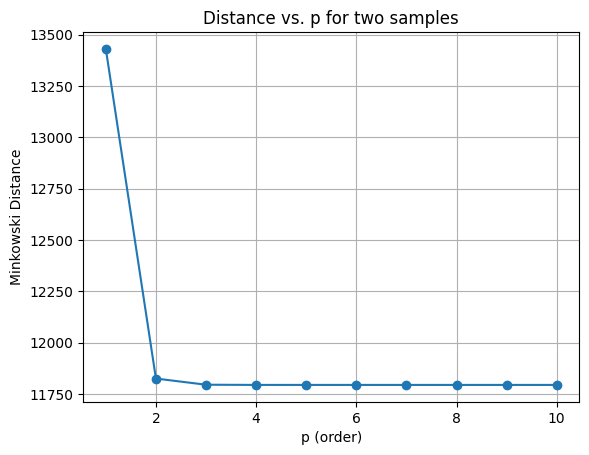

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

numeric_label_df = label_df.drop(columns=['ID', 'Dt_Customer'])
vec1 = numeric_label_df.iloc[0].values
vec2 = numeric_label_df.iloc[1].values

p_values = range(1, 11)
distances = [minkowski_distance(vec1, vec2, p) for p in p_values]

plt.plot(p_values, distances, marker='o')
plt.xlabel('p (order)')
plt.ylabel('Minkowski Distance')
plt.title('Distance vs. p for two samples')
plt.grid(True)
plt.show()

In [14]:
from scipy.spatial.distance import minkowski as scipy_minkowski
import numpy as np
import pandas as pd
for p in [1, 2, 5, 10]:
    our_dist = minkowski_distance(vec1, vec2, p)
    scipy_dist = scipy_minkowski(vec1, vec2, p)
    print(f"p={p}: Our={our_dist:.6f}, SciPy={scipy_dist:.6f}, diff={abs(our_dist-scipy_dist):.2e}")

p=1: Our=13431.000000, SciPy=13431.000000, diff=0.00e+00
p=2: Our=11825.004228, SciPy=11825.004228, diff=0.00e+00
p=5: Our=11794.001454, SciPy=11794.001454, diff=0.00e+00
p=10: Our=11794.000000, SciPy=11794.000000, diff=0.00e+00


In [17]:
import numpy as np
import pandas as pd

def dot_product(a, b):
    """Dot product of two vectors."""
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) != len(b):
        raise ValueError("Vectors must have same length")
    return np.sum(a * b)

def euclidean_norm(a):
    """Euclidean (L2) norm of a vector."""
    a = np.asarray(a)
    return np.sqrt(np.sum(a ** 2))

A = numeric_label_df.iloc[0].values
B = numeric_label_df.iloc[1].values

our_dot = dot_product(A, B)
numpy_dot = np.dot(A, B)

our_norm = euclidean_norm(A)
numpy_norm = np.linalg.norm(A)

print(f"Dot: ours={our_dot}, numpy={numpy_dot}")
print(f"Norm: ours={our_norm}, numpy={numpy_norm}")

Dot: ours=2698185180.0, numpy=2698185180.0
Norm: ours=58177.44238964102, numpy=58177.44238964102


In [18]:
import numpy as np
import pandas as pd

def mean_vector(X):
    """Column-wise mean of matrix X (2D array)."""
    X = np.asarray(X)
    return np.mean(X, axis=0)   # Could also use sum / rows

def variance_vector(X, ddof=0):
    """Column-wise variance (population by default)."""
    X = np.asarray(X)
    mu = mean_vector(X)
    return np.mean((X - mu) ** 2, axis=0)

def std_vector(X, ddof=0):
    """Column-wise standard deviation."""
    return np.sqrt(variance_vector(X, ddof=ddof))

In [21]:
import numpy as np
import pandas as pd


X = numeric_label_df.values

our_mean = mean_vector(X)
numpy_mean = np.mean(X, axis=0)

our_std = std_vector(X, ddof=0)
numpy_std = np.std(X, axis=0, ddof=0)

print("Mean comparison (first 5):")
print("Our:", our_mean[:5])
print("NumPy:", numpy_mean[:5])
print("Diff:", np.abs(our_mean[:5] - numpy_mean[:5]))

print("\nStd comparison (first 5):")
print("Our:", our_std[:5])
print("NumPy:", numpy_std[:5])
print("Diff:", np.abs(our_std[:5] - numpy_std[:5]))

Mean comparison (first 5):
Our: [1.96880580e+03 2.39375000e+00 3.72991071e+00            nan
 4.44196429e-01]
NumPy: [1.96880580e+03 2.39375000e+00 3.72991071e+00            nan
 4.44196429e-01]
Diff: [ 0.  0.  0. nan  0.]

Std comparison (first 5):
Our: [11.98139414  1.12454604  1.07603687         nan  0.53827791]
NumPy: [11.98139414  1.12454604  1.07603687         nan  0.53827791]
Diff: [ 0.  0.  0. nan  0.]


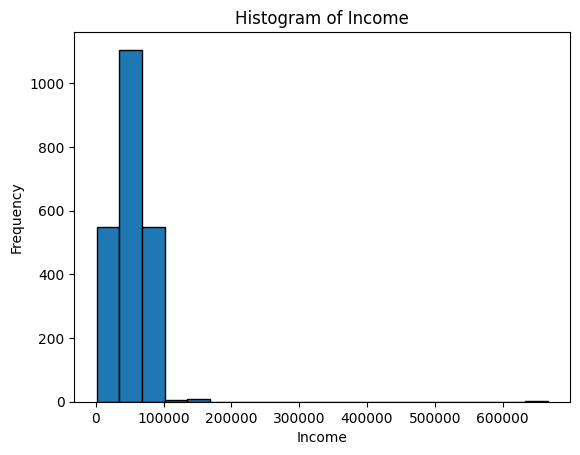

Mean of Income: 52247.25
Variance of Income: 633397830.19
Histogram counts: [ 548 1106  549    5    7    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    1]


In [25]:
import numpy as np
import pandas as pd3

feature = 'Income'
data = df[feature].dropna()

plt.hist(data, bins=20, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.show()


mean_val = mean_vector(data.values.reshape(-1,1))[0]
var_val = variance_vector(data.values.reshape(-1,1), ddof=0)[0]

print(f"Mean of {feature}: {mean_val:.2f}")
print(f"Variance of {feature}: {var_val:.2f}")

counts, bin_edges = np.histogram(data, bins=20)
print("Histogram counts:", counts)

In [28]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
class KNN:
    def __init__(self, k=3, p=2):
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):

        distances = np.array([np.power(np.sum(np.abs(x - x_train)**self.p), 1/self.p) for x_train in self.X_train])
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

from collections import Counter

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

df.drop('ID', axis=1, inplace=True)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Customer_Since_Year'] = df['Dt_Customer'].dt.year
df.drop('Dt_Customer', axis=1, inplace=True)

def label_encode(series):
    unique_vals = series.unique()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    return series.map(mapping), mapping

def one_hot_encode(series, prefix=None):
    unique_vals = series.unique()
    if prefix is None:
        prefix = series.name
    one_hot = pd.DataFrame()
    for val in unique_vals:
        col_name = f"{prefix}_{val}"
        one_hot[col_name] = (series == val).astype(int)
    return one_hot

ordinal_features = ['Education']
nominal_features = ['Marital_Status']

for col in ordinal_features:
    df[col + '_encoded'], _ = label_encode(df[col])
    df.drop(col, axis=1, inplace=True)

one_hot_dfs = []
for col in nominal_features:
    oh = one_hot_encode(df[col], prefix=col)
    one_hot_dfs.append(oh)
    df.drop(col, axis=1, inplace=True)
df = pd.concat([df] + one_hot_dfs, axis=1)


y = df['Response'].values
X = df.drop('Response', axis=1).values

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNN(k=5, p=2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"KNN (k=5, Euclidean) accuracy: {accuracy:.4f}")

for k in [3, 5, 7]:
    for p in [1, 2]:
        knn = KNN(k=k, p=p)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"k={k}, p={p} (Manhattan if p=1, Euclid if p=2) -> accuracy: {acc:.4f}")

KNN (k=5, Euclidean) accuracy: 0.8371
k=3, p=1 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8371
k=3, p=2 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8304
k=5, p=1 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8393
k=5, p=2 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8371
k=7, p=1 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8482
k=7, p=2 (Manhattan if p=1, Euclid if p=2) -> accuracy: 0.8415
